# Spotify Top 50 – globális zenei trendek és népszerűség előrejelzés

Ez a notebook a Spotify Top 50 dalok zenei jellemzőit elemzi, feltárja az összefüggéseket, majd prediktív modellekkel megpróbálja megbecsülni egy dal várható népszerűségét.

**Módszertani keret:** CRISP-DM  
1. üzleti/projektcél,  
2. adatmegértés,  
3. adatelőkészítés,  
4. modellezés,  
5. kiértékelés,  
6. következtetések.

## 1. Projektcél 

A notebooknak az alábbiakat kell teljesítenie:  
- részletes feltáró adatelemzés a zenei jellemzőkről,  
- a jellemzők közötti összefüggések vizsgálata,  
- annak elemzése, mely tulajdonságok befolyásolják leginkább a sikerességet,  
- látványos és informatív vizualizációk készítése,  
- prediktív modell építése a népszerűség becslésére,  
- szakmailag értelmezett következtetések levonása.



In [1]:
# Könyvtárak importálása és alapbeállítások
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown, HTML

from scipy.stats import pearsonr, f_oneway, shapiro
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Megjelenítés finomhangolása, hogy a hosszabb mondatok és táblázatok se vágódjanak le
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.expand_frame_repr", False)

plt.style.use("default")
sns.set_theme(style="whitegrid", context="notebook")

display(HTML("""
<style>
div.output_area pre {
    white-space: pre-wrap !important;
}
.dataframe td, .dataframe th {
    white-space: normal !important;
    max-width: 420px;
}
.jp-RenderedHTMLCommon table {
    table-layout: auto;
    width: 100%;
}
</style>
"""))



## 2. Adatbetöltés

In [2]:
# Adatbetöltés: helyi CSV előnyben, szükség esetén automatikus keresés / letöltés
import os
import shutil

os.makedirs("Adatok", exist_ok=True)

search_paths = [
    Path("Adatok/Top-50-musicality-global.csv"),
    Path("Top-50-musicality-global.csv"),
    Path("spotify.csv"),
    Path("spotify_tracks.csv"),
    Path("dataset.csv")
]

def find_first_csv():
    # Első kör: tipikus fájlnevek
    for p in search_paths:
        if p.exists():
            return p

    # Második kör: bármely CSV az aktuális mappában vagy az Adatok mappában
    candidate_dirs = [Path("."), Path("Adatok")]
    for base in candidate_dirs:
        if base.exists():
            csvs = sorted(base.glob("*.csv"))
            if csvs:
                return csvs[0]

    return None

csv_path = find_first_csv()

if csv_path is None:
    try:
        import kagglehub

        print("Helyi CSV nem található, megpróbálom letölteni a Kaggle adatkészletet...")
        dataset_path = Path(
            kagglehub.dataset_download("miquelneck/worlds-spotify-top-50-playlist-musicality-data")
        )

        downloaded_csvs = sorted(dataset_path.glob("*.csv"))
        if not downloaded_csvs:
            raise FileNotFoundError("A letöltött Kaggle mappában nem található CSV fájl.")

        csv_path = downloaded_csvs[0]
        target_path = Path("Adatok") / csv_path.name
        if not target_path.exists():
            shutil.copy(csv_path, target_path)
        csv_path = target_path

    except Exception as e:
        raise FileNotFoundError(
            "Nem találtam betölthető CSV fájlt. Másold a Spotify adatkészlet CSV-jét a notebook mellé "
            "vagy az 'Adatok' mappába. Részletek: " + str(e)
        )

df_raw = pd.read_csv(csv_path)

display(Markdown(f"**Betöltött fájl:** `{csv_path}`"))
print("Adatok mérete:", df_raw.shape)
display(df_raw.head())



Helyi CSV nem található, megpróbálom letölteni a Kaggle adatkészletet...


**Betöltött fájl:** `Adatok\Top-50-musicality-global.csv`

Adatok mérete: (3589, 21)


,Unnamed: 0,Country,Track Name,Artist Name,Album Name,Popularity,Date,Markets,Danceability,Acousticness,duration,Energy,Instrumentalness,Key,Liveness,Loudness,Mode,Speechiness,Tempo,TSignature,Positiveness
0,0,Global,Standing Next to You,Jung Kook,GOLDEN,91,2023-11-03,AR,0.711,0.0447,206020,0.809,0.0,2,0.3390,-4.389,0,0.0955,106.017,4,0.816
1,1,Global,greedy,Tate McRae,greedy,100,2023-09-15,AR,0.750,0.2560,131872,0.733,0.0,6,0.1140,-3.180,0,0.0319,111.018,1,0.844
2,2,Global,Si No Estás,iñigo quintero,Si No Estás,99,2022-09-23,AR,0.537,0.8270,184061,0.421,0.0,5,0.1380,-8.720,1,0.0285,98.224,4,0.524
3,3,Global,Seven (feat. Latto) (Explicit Ver.),Jung Kook,GOLDEN,82,2023-11-03,AR,0.790,0.3120,183551,0.831,0.0,11,0.0797,-4.185,1,0.0440,124.987,4,0.872
4,4,Global,Is It Over Now? (Taylor's Version) (From The Vault),Taylor Swift,1989 (Taylor's Version),93,2023-10-26,AR,0.596,0.0504,229478,0.658,0.0,0,0.1270,-7.346,1,0.0360,100.012,4,0.176


## 3. Adatmegértés és előkészítés

In [3]:
# Másolat készítése, hogy az eredeti betöltött adatok megmaradjanak
df = df_raw.copy()

# Lehetséges oszlopnevek egységesítése
column_mapping = {
    "track_id": "Track_ID",
    "track_name": "Track_Name",
    "track_artist": "Artist_Name",
    "track_popularity": "Popularity",
    "track_album_id": "Album_ID",
    "track_album_name": "Album_Name",
    "track_album_release_date": "Release_Date",
    "playlist_name": "Playlist_Name",
    "playlist_id": "Playlist_ID",
    "playlist_genre": "Genre",
    "playlist_subgenre": "Subgenre",
    "danceability": "Danceability",
    "energy": "Energy",
    "key": "Key",
    "loudness": "Loudness",
    "mode": "Mode",
    "speechiness": "Speechiness",
    "acousticness": "Acousticness",
    "instrumentalness": "Instrumentalness",
    "liveness": "Liveness",
    "valence": "Positiveness",
    "tempo": "Tempo",
    "duration_ms": "Duration_ms",
    "date": "Date",
    "country": "Country",
    "chart_country": "Country",
    "market": "Country",
    "region": "Region",
    "artist_country": "Artist_Country",
}

existing_mapping = {k: v for k, v in column_mapping.items() if k in df.columns}
df = df.rename(columns=existing_mapping)

print("Oszlopok a tisztítás után:")
print(df.columns.tolist())

Oszlopok a tisztítás után:
['Unnamed: 0', 'Country', 'Track Name', 'Artist Name', 'Album Name', 'Popularity', 'Date', 'Markets', 'Danceability', 'Acousticness', 'duration', 'Energy', 'Instrumentalness', 'Key', 'Liveness', 'Loudness', 'Mode', 'Speechiness', 'Tempo', 'TSignature', 'Positiveness']


In [4]:
# Hiányzó értékek vizsgálata
missing_df = pd.DataFrame({
    "Hiányzó darab": df.isna().sum(),
    "Hiányzó arány (%)": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values("Hiányzó arány (%)", ascending=False)

missing_df[missing_df["Hiányzó darab"] > 0]

,Hiányzó darab,Hiányzó arány (%)
Track Name,6,0.17
Album Name,6,0.17
Artist Name,6,0.17
Markets,6,0.17


In [5]:
# Hiányzó értékek kezelése
text_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in text_cols:
    df[col] = df[col].fillna("Ismeretlen")

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Dátumkezelés
date_col = None
for candidate in ["Release_Date", "Date"]:
    if candidate in df.columns:
        date_col = candidate
        break

if date_col is not None:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df["Release_Year"] = df[date_col].dt.year
    df["Release_Month"] = df[date_col].dt.month

    def get_season(month):
        if pd.isna(month):
            return "Ismeretlen"
        if month in [12, 1, 2]:
            return "Tél"
        if month in [3, 4, 5]:
            return "Tavasz"
        if month in [6, 7, 8]:
            return "Nyár"
        return "Ősz"

    df["Release_Season"] = df["Release_Month"].apply(get_season)

# Hossz percben
if "Duration_ms" in df.columns:
    df["Duration_min"] = df["Duration_ms"] / 60000

print(f"Összes hiányzó érték a tisztítás után: {df.isna().sum().sum()}")
df.head()

Összes hiányzó érték a tisztítás után: 63


,Unnamed: 0,Country,Track Name,Artist Name,Album Name,Popularity,Date,Markets,Danceability,Acousticness,duration,Energy,Instrumentalness,Key,Liveness,Loudness,Mode,Speechiness,Tempo,TSignature,Positiveness,Release_Year,Release_Month,Release_Season
0,0,Global,Standing Next to You,Jung Kook,GOLDEN,91,2023-11-03,AR,0.711,0.0447,206020,0.809,0.0,2,0.3390,-4.389,0,0.0955,106.017,4,0.816,2023.0,11.0,Ősz
1,1,Global,greedy,Tate McRae,greedy,100,2023-09-15,AR,0.750,0.2560,131872,0.733,0.0,6,0.1140,-3.180,0,0.0319,111.018,1,0.844,2023.0,9.0,Ősz
2,2,Global,Si No Estás,iñigo quintero,Si No Estás,99,2022-09-23,AR,0.537,0.8270,184061,0.421,0.0,5,0.1380,-8.720,1,0.0285,98.224,4,0.524,2022.0,9.0,Ősz
3,3,Global,Seven (feat. Latto) (Explicit Ver.),Jung Kook,GOLDEN,82,2023-11-03,AR,0.790,0.3120,183551,0.831,0.0,11,0.0797,-4.185,1,0.0440,124.987,4,0.872,2023.0,11.0,Ősz
4,4,Global,Is It Over Now? (Taylor's Version) (From The Vault),Taylor Swift,1989 (Taylor's Version),93,2023-10-26,AR,0.596,0.0504,229478,0.658,0.0,0,0.1270,-7.346,1,0.0360,100.012,4,0.176,2023.0,10.0,Ősz


In [6]:
# Alapinformációk és statisztikák
print("Numerikus oszlopok száma:", df.select_dtypes(include=[np.number]).shape[1])
display(df.describe(include="all").T.head(20))

Numerikus oszlopok száma: 17


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Unnamed: 0,3589.0,NaN,NaN,NaN,1794.0,0.0,897.0,1794.0,2691.0,3588.0,1036.199386
Country,3589,72,Global,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Track Name,3589,1842,greedy,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Artist Name,3589,1158,Bad Bunny,163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Album Name,3589,1546,nadie sabe lo que va a pasar mañana,153,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Popularity,3589.0,NaN,NaN,NaN,78.451101,0.0,67.0,83.0,90.0,100.0,15.24271
Date,3568,NaN,NaN,NaN,2022-04-30 20:35:47.085201,1942-01-01 00:00:00,2023-01-17 18:00:00,2023-07-21 00:00:00,2023-10-04 00:00:00,2023-11-08 00:00:00,NaN
Markets,3589,11,AR,3527,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Danceability,3589.0,NaN,NaN,NaN,0.688079,0.244,0.596,0.706,0.795,0.974,0.135642
Acousticness,3589.0,NaN,NaN,NaN,0.285637,0.000008,0.0796,0.188,0.441,0.984,0.258611


## 4. Feltáró adatelemzés (EDA)

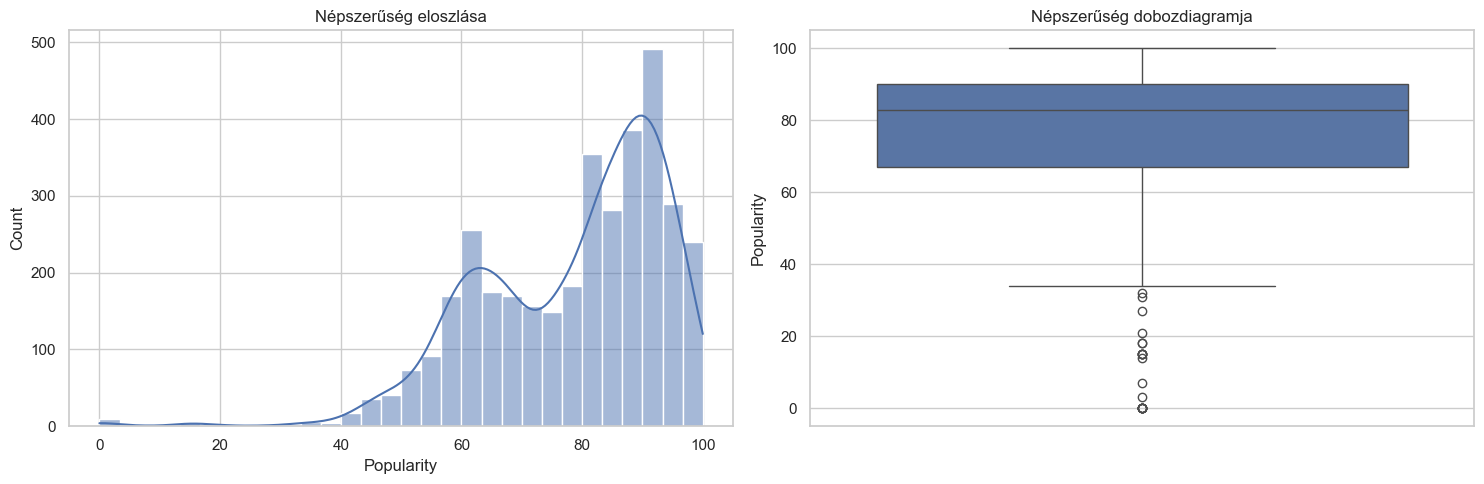

,Érték
Átlag,78.451
Medián,83.000
Szórás,15.243
Minimum,0.000
Maximum,100.000
Ferdeség,-0.985
Csúcsosság,1.441


In [7]:
# A célváltozó: népszerűség
if "Popularity" not in df.columns:
    raise KeyError("A 'Popularity' oszlop nem található, ezért a modell nem építhető fel.")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df["Popularity"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Népszerűség eloszlása")
axes[0].set_xlabel("Popularity")

sns.boxplot(y=df["Popularity"], ax=axes[1])
axes[1].set_title("Népszerűség dobozdiagramja")
axes[1].set_ylabel("Popularity")

plt.tight_layout()
plt.show()

pop_summary = pd.Series({
    "Átlag": df["Popularity"].mean(),
    "Medián": df["Popularity"].median(),
    "Szórás": df["Popularity"].std(),
    "Minimum": df["Popularity"].min(),
    "Maximum": df["Popularity"].max(),
    "Ferdeség": df["Popularity"].skew(),
    "Csúcsosság": df["Popularity"].kurtosis(),
}).round(3)

pop_summary.to_frame("Érték")

In [8]:
# Zenei jellemzők kiválasztása EDA-hoz
candidate_audio_features = [
    "Danceability", "Energy", "Loudness", "Speechiness",
    "Acousticness", "Instrumentalness", "Liveness",
    "Positiveness", "Tempo", "Duration_min"
]

audio_features = [col for col in candidate_audio_features if col in df.columns]
audio_features

['Danceability',
 'Energy',
 'Loudness',
 'Speechiness',
 'Acousticness',
 'Instrumentalness',
 'Liveness',
 'Positiveness',
 'Tempo']

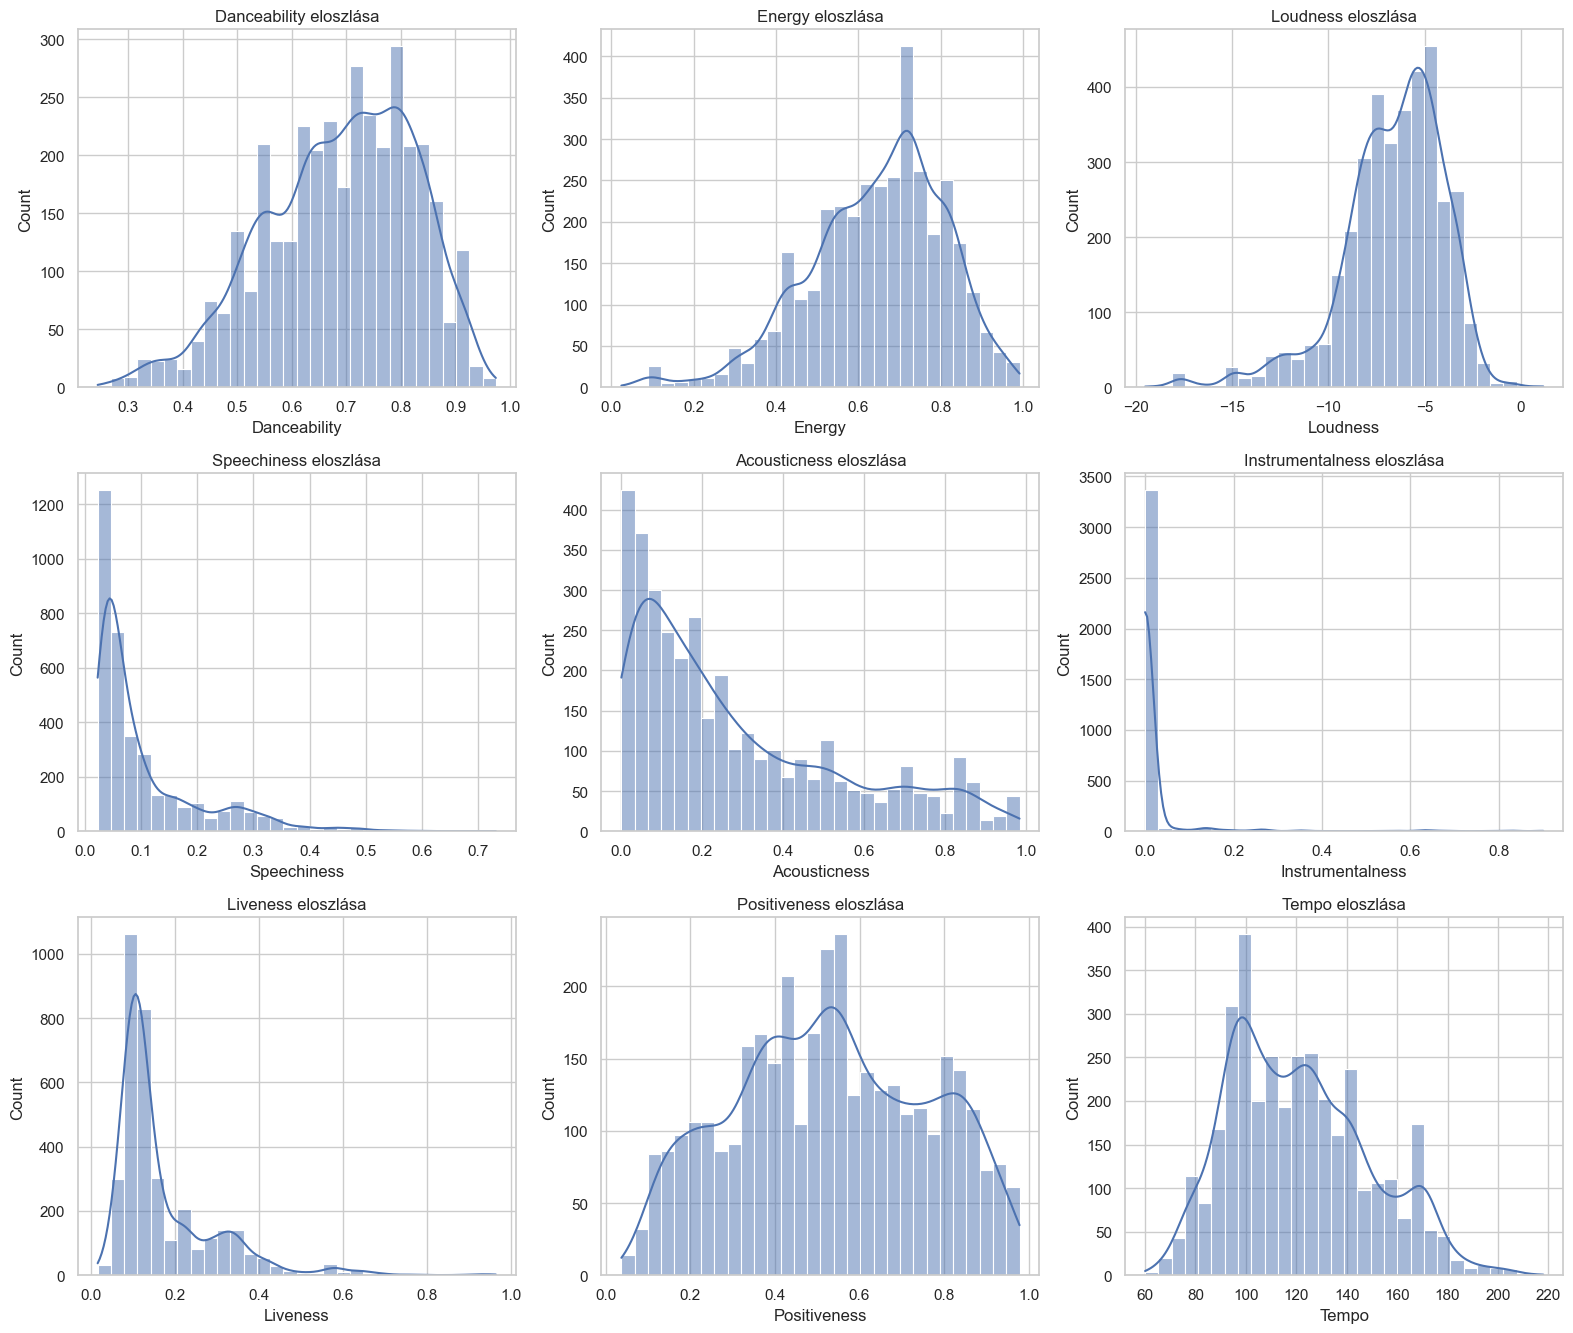

In [9]:
# Eloszlások vizsgálata
n_cols = 3
n_rows = int(np.ceil(len(audio_features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, audio_features):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f"{col} eloszlása")

for ax in axes[len(audio_features):]:
    ax.remove()

plt.tight_layout()
plt.show()

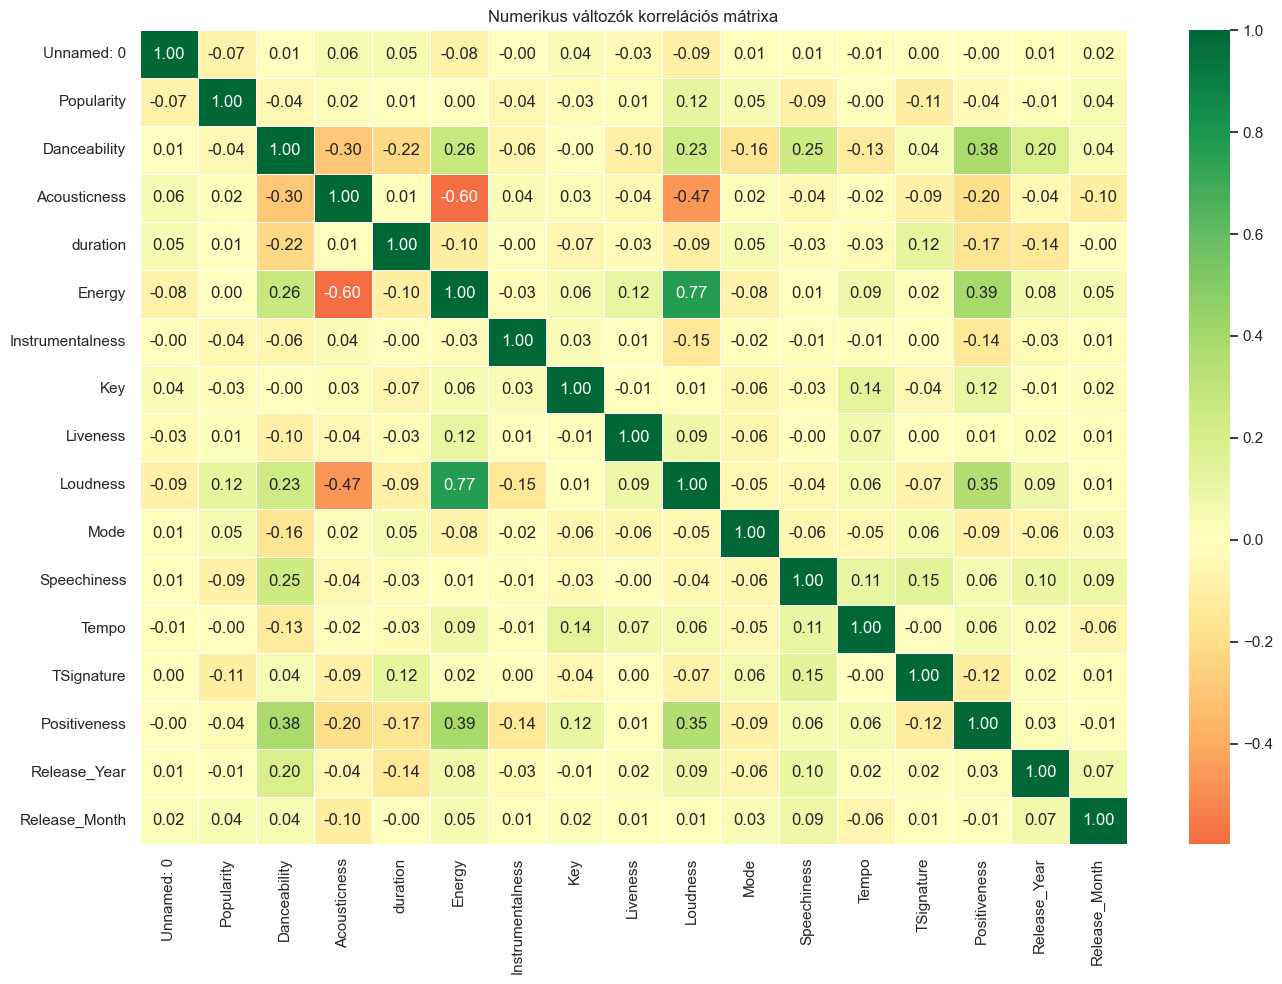

,Korreláció a Popularity-vel
Loudness,0.119866
Mode,0.054440
Release_Month,0.041230
Acousticness,0.015483
Liveness,0.013888
duration,0.006042
Energy,0.002629
Tempo,-0.002462
Release_Year,-0.010218
Key,-0.028023


In [10]:
# Korrelációs mátrix
numeric_df = df.select_dtypes(include=[np.number]).copy()
corr_matrix = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", center=0, linewidths=0.5)
plt.title("Numerikus változók korrelációs mátrixa")
plt.tight_layout()
plt.show()

corr_with_popularity = corr_matrix["Popularity"].drop("Popularity").sort_values(ascending=False)
corr_with_popularity.to_frame("Korreláció a Popularity-vel")

In [11]:
# Részletes korrelációs és szignifikancia elemzés
corr_results = []

for col in numeric_df.columns:
    if col == "Popularity":
        continue
    if numeric_df[col].nunique() <= 1:
        continue

    valid = df[[col, "Popularity"]].dropna()
    corr, p_value = pearsonr(valid[col], valid["Popularity"])
    corr_results.append({
        "Jellemző": col,
        "Pearson-korreláció": corr,
        "p-érték": p_value,
        "Szignifikáns (p<0.05)": p_value < 0.05
    })

corr_df = pd.DataFrame(corr_results).sort_values("Pearson-korreláció", ascending=False)
corr_df

,Jellemző,Pearson-korreláció,p-érték,Szignifikáns (p<0.05)
8,Loudness,0.119866,5.827610e-13,True
9,Mode,0.054440,1.103560e-03,True
15,Release_Month,0.041230,1.377851e-02,True
2,Acousticness,0.015483,3.537685e-01,False
7,Liveness,0.013888,4.055597e-01,False
3,duration,0.006042,7.174702e-01,False
4,Energy,0.002629,8.748836e-01,False
11,Tempo,-0.002462,8.827871e-01,False
14,Release_Year,-0.010218,5.417752e-01,False
6,Key,-0.028023,9.323568e-02,False


In [12]:
# Műfajok szerinti elemzés (ha elérhető)
genre_col = None
for candidate in ["Genre", "playlist_genre"]:
    if candidate in df.columns:
        genre_col = candidate
        break

if genre_col is not None:
    genre_summary = (
        df.groupby(genre_col)["Popularity"]
        .agg(["count", "mean", "median", "std"])
        .sort_values("mean", ascending=False)
        .round(2)
    )
    display(genre_summary)

    plt.figure(figsize=(12, 6))
    order = genre_summary.index.tolist()
    sns.boxplot(data=df, x=genre_col, y="Popularity", order=order)
    plt.title("Népszerűség megoszlása műfajok szerint")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    genre_groups = [df[df[genre_col] == genre]["Popularity"].dropna() for genre in df[genre_col].dropna().unique()]
    if len(genre_groups) >= 2:
        genre_f_stat, genre_p_value = f_oneway(*genre_groups)
        print(f"ANOVA p-érték műfajokra: {genre_p_value:.4f}")
else:
    print("Műfaj oszlop nem érhető el ebben az adathalmazban.")

Műfaj oszlop nem érhető el ebben az adathalmazban.


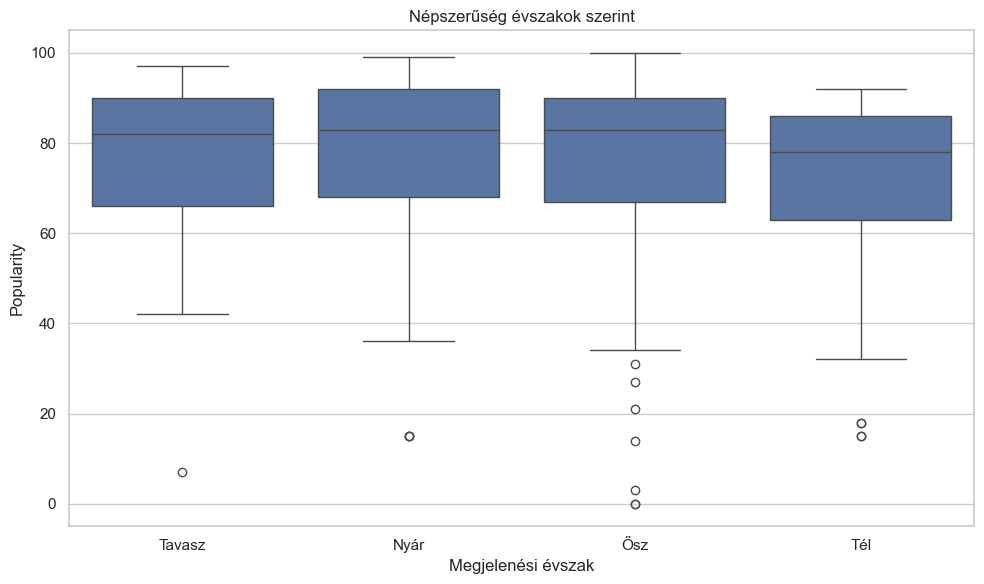

ANOVA p-érték évszakokra: 0.0000


In [13]:
# Évszak szerinti elemzés (ha dátuminformáció rendelkezésre áll)
if "Release_Season" in df.columns:
    season_order = ["Tavasz", "Nyár", "Ősz", "Tél"]
    plot_df = df[df["Release_Season"].isin(season_order)].copy()

    if not plot_df.empty:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=plot_df, x="Release_Season", y="Popularity", order=season_order)
        plt.title("Népszerűség évszakok szerint")
        plt.xlabel("Megjelenési évszak")
        plt.ylabel("Popularity")
        plt.tight_layout()
        plt.show()

        season_groups = [
            plot_df.loc[plot_df["Release_Season"] == season, "Popularity"].dropna()
            for season in season_order
            if season in plot_df["Release_Season"].values
        ]
        if len(season_groups) >= 2:
            season_f_stat, season_p_value = f_oneway(*season_groups)
            print(f"ANOVA p-érték évszakokra: {season_p_value:.4f}")
else:
    print("Nincs dátum alapú évszakinformáció.")

## 6. Országonkénti népszerűségi tényezők

In [14]:
# Lehetséges ország / régió oszlop automatikus felismerése
geo_candidates = [
    "Country", "country", "Chart_Country", "chart_country",
    "Market", "market", "Region", "region",
    "Artist_Country", "artist_country"
]

geo_col = next((col for col in geo_candidates if col in df.columns), None)

country_feature_candidates = [
    col for col in [
        "Danceability", "Energy", "Loudness", "Tempo",
        "Speechiness", "Acousticness", "Instrumentalness",
        "Liveness", "Positiveness", "Duration_min"
    ]
    if col in df.columns
]

country_mean_df = pd.DataFrame()
country_importance_df = pd.DataFrame()
country_corr_matrix = pd.DataFrame()

if geo_col is None:
    display(Markdown(
        "> **Megjegyzés:** az aktuális adatkészletben nem található egyértelmű ország- vagy régiómező, "
        "ezért az országonkénti bontás nem futtatható automatikusan."
    ))
else:
    country_df = df[[geo_col, "Popularity"] + country_feature_candidates].copy()
    country_df[geo_col] = country_df[geo_col].astype(str).str.strip()
    country_df = country_df[
        country_df[geo_col].notna()
        & (country_df[geo_col] != "")
        & (country_df[geo_col].str.lower() != "nan")
        & (country_df[geo_col].str.lower() != "unknown")
    ].copy()

    country_counts = country_df[geo_col].value_counts()
    valid_countries = country_counts[country_counts >= 5].index
    country_df = country_df[country_df[geo_col].isin(valid_countries)].copy()

    if country_df.empty:
        display(Markdown(
            "> **Megjegyzés:** találtunk földrajzi oszlopot, de nincs elég megfigyelés az országonkénti "
            "stabil összehasonlításhoz (minimum 5 rekord / ország)."
        ))
    else:
        country_mean_df = (
            country_df.groupby(geo_col)[country_feature_candidates + ["Popularity"]]
            .mean()
            .round(3)
            .sort_values("Popularity", ascending=False)
        )

        display(Markdown(f"### Országonkénti átlagos zenei jellemzők és népszerűség ({geo_col})"))
        display(
            country_mean_df.style
            .format(precision=3)
            .set_properties(**{"text-align": "left", "white-space": "normal"})
            .set_table_styles([
                {"selector": "th", "props": [("text-align", "left")]},
                {"selector": "td", "props": [("max-width", "140px")]},
            ])
        )


### Országonkénti átlagos zenei jellemzők és népszerűség (Country)

,Danceability,Energy,Loudness,Tempo,Speechiness,Acousticness,Instrumentalness,Liveness,Positiveness,Popularity
Country,,,,,,,,,,
Global,0.658,0.632,-6.667,115.733,0.080,0.282,0.013,0.179,0.475,92.260
AUS,0.639,0.625,-7.149,122.745,0.080,0.267,0.012,0.184,0.485,90.620
USA,0.639,0.641,-6.875,126.794,0.086,0.262,0.014,0.185,0.449,90.420
CAN,0.632,0.616,-6.939,126.726,0.078,0.271,0.006,0.170,0.426,90.160
ARE,0.654,0.629,-6.988,113.765,0.086,0.251,0.007,0.161,0.483,89.580
GBR,0.606,0.655,-6.692,122.821,0.083,0.264,0.014,0.177,0.464,88.520
HND,0.746,0.710,-4.940,121.750,0.121,0.255,0.013,0.177,0.561,88.480
NZL,0.653,0.617,-7.072,123.317,0.083,0.276,0.012,0.164,0.495,88.440
NIC,0.757,0.683,-5.294,118.123,0.120,0.235,0.020,0.163,0.587,87.800


In [15]:
# Országonként a legerősebb népszerűségi tényező meghatározása
if geo_col is not None and not country_mean_df.empty:
    factor_rows = []
    corr_rows = []

    for country_name, group in country_df.groupby(geo_col):
        sub = group[country_feature_candidates + ["Popularity"]].dropna()

        if len(sub) < 5:
            continue

        corr_series = sub.corr(numeric_only=True)["Popularity"].drop("Popularity").dropna()

        if corr_series.empty:
            continue

        strongest_feature = corr_series.abs().idxmax()

        factor_rows.append({
            "Ország": country_name,
            "Mintanagyság": len(sub),
            "Legfontosabb tényező": strongest_feature,
            "Korreláció": corr_series[strongest_feature],
            "Átlagos népszerűség": sub["Popularity"].mean()
        })

        corr_record = {"Ország": country_name}
        for feature_name in country_feature_candidates:
            corr_record[feature_name] = corr_series.get(feature_name, np.nan)
        corr_rows.append(corr_record)

    country_importance_df = (
        pd.DataFrame(factor_rows)
        .sort_values(["Átlagos népszerűség", "Korreláció"], ascending=[False, False])
        .reset_index(drop=True)
    )

    country_corr_matrix = (
        pd.DataFrame(corr_rows)
        .set_index("Ország")
        .sort_index()
    )

    if not country_importance_df.empty:
        display(Markdown("### Országonként mi a legerősebb népszerűségi tényező?"))
        display(
            country_importance_df.style
            .format({
                "Korreláció": "{:.3f}",
                "Átlagos népszerűség": "{:.2f}"
            })
            .hide(axis="index")
            .set_properties(**{"text-align": "left", "white-space": "normal"})
            .set_table_styles([
                {"selector": "th", "props": [("text-align", "left")]},
                {"selector": "td", "props": [("max-width", "180px")]},
            ])
        )

        dominant_feature_summary = (
            country_importance_df.groupby("Legfontosabb tényező")
            .agg(
                Országok_száma=("Ország", "count"),
                Átlagos_korreláció=("Korreláció", "mean"),
                Átlagos_népszerűség=("Átlagos népszerűség", "mean")
            )
            .sort_values(["Országok_száma", "Átlagos_korreláció"], ascending=[False, False])
            .round(3)
        )

        display(Markdown(
            "### Mely tényezők dominálnak a leggyakrabban országonként? "
            "(országok szerinti átlaggal)"
        ))
        display(
            dominant_feature_summary.style
            .set_properties(**{"text-align": "left", "white-space": "normal"})
            .set_table_styles([
                {"selector": "th", "props": [("text-align", "left")]},
                {"selector": "td", "props": [("max-width", "180px")]},
            ])
        )


### Országonként mi a legerősebb népszerűségi tényező?

Ország,Mintanagyság,Legfontosabb tényező,Korreláció,Átlagos népszerűség
Global,50,Tempo,0.295,92.26
AUS,50,Energy,-0.197,90.62
USA,50,Instrumentalness,-0.334,90.42
CAN,50,Energy,-0.223,90.16
ARE,50,Energy,-0.323,89.58
GBR,50,Instrumentalness,-0.407,88.52
HND,50,Positiveness,-0.246,88.48
NZL,50,Positiveness,-0.368,88.44
NIC,50,Liveness,0.211,87.80
GTM,50,Tempo,-0.227,87.46


### Mely tényezők dominálnak a leggyakrabban országonként? (országok szerinti átlaggal)

,Országok_száma,Átlagos_korreláció,Átlagos_népszerűség
Legfontosabb tényező,,,
Danceability,15,0.057000,77.267000
Positiveness,13,-0.072000,77.506000
Energy,13,-0.208000,79.766000
Acousticness,11,0.172000,77.673000
Speechiness,8,-0.160000,76.800000
Instrumentalness,5,-0.085000,85.392000
Loudness,3,0.385000,74.293000
Liveness,2,0.228000,74.230000
Tempo,2,0.034000,89.860000


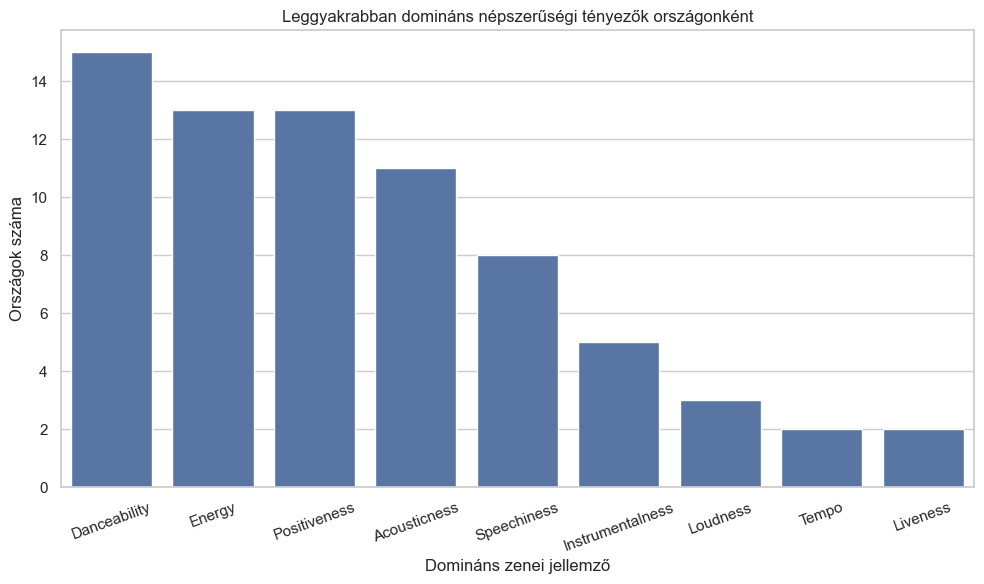

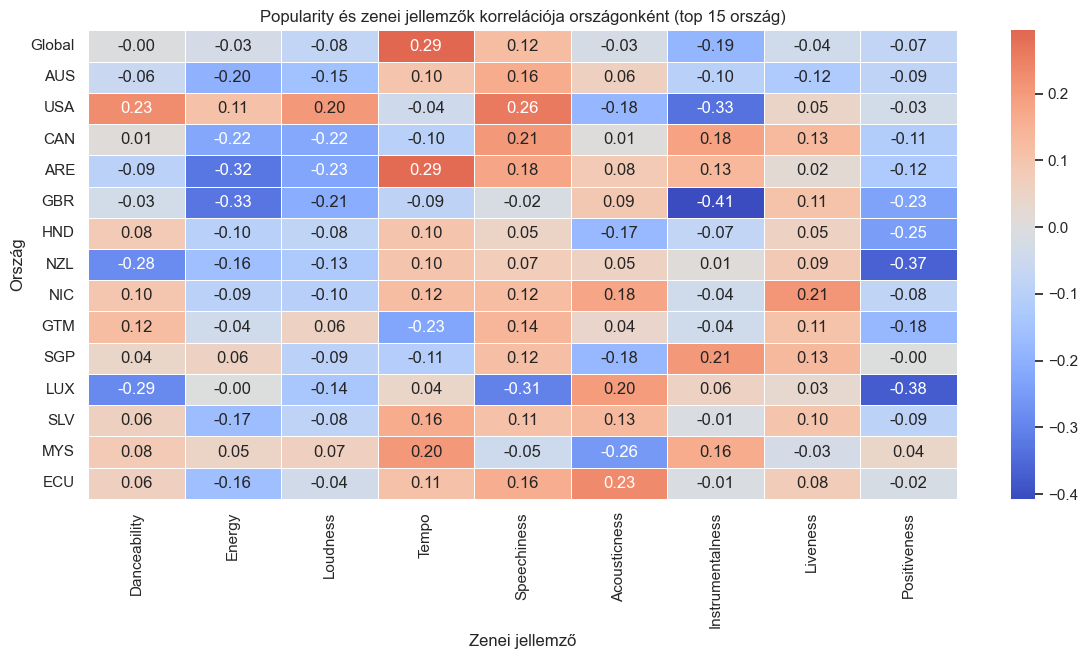

In [16]:
# Országonkénti vizualizációk: domináns tényezők + hőtérkép
if geo_col is not None and not country_importance_df.empty and not country_corr_matrix.empty:
    plt.figure(figsize=(10, 6))
    order = country_importance_df["Legfontosabb tényező"].value_counts().index
    sns.countplot(
        data=country_importance_df,
        x="Legfontosabb tényező",
        order=order
    )
    plt.title("Leggyakrabban domináns népszerűségi tényezők országonként")
    plt.xlabel("Domináns zenei jellemző")
    plt.ylabel("Országok száma")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    heatmap_countries = (
        country_importance_df.sort_values("Átlagos népszerűség", ascending=False)["Ország"]
        .head(15)
        .tolist()
    )

    plt.figure(figsize=(12, max(6, len(heatmap_countries) * 0.45)))
    sns.heatmap(
        country_corr_matrix.loc[heatmap_countries],
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )
    plt.title("Popularity és zenei jellemzők korrelációja országonként (top 15 ország)")
    plt.xlabel("Zenei jellemző")
    plt.ylabel("Ország")
    plt.tight_layout()
    plt.show()


## 5. Prediktív modellezés
  
A célváltozó itt a **Popularity**, a bemeneti változók pedig a numerikus zenei jellemzők.

In [17]:
# Modellváltozók kijelölése
base_feature_candidates = [
    "Danceability", "Energy", "Key", "Loudness", "Mode",
    "Speechiness", "Acousticness", "Instrumentalness",
    "Liveness", "Positiveness", "Tempo", "Duration_min"
]

model_features = [col for col in base_feature_candidates if col in df.columns]
model_df = df[model_features + ["Popularity"]].dropna().copy()

X = model_df[model_features]
y = model_df["Popularity"]

print("Felhasznált jellemzők:")
print(model_features)
print(f"Modellezési mintaelemszám: {len(model_df)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Felhasznált jellemzők:
['Danceability', 'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Positiveness', 'Tempo']
Modellezési mintaelemszám: 3589
X_train: (2871, 11)
X_test : (718, 11)
y_train: (2871,)
y_test : (718,)


In [18]:
# Skálázás
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Positiveness,Tempo
2718,1.287756,-0.465124,-0.088494,0.404635,0.991330,-0.377501,-0.771889,-0.195668,1.098053,0.143003,-0.943347
1123,-1.218113,-1.736765,1.626232,-0.422913,-1.008746,-0.724789,2.147561,-0.195622,-0.417229,-1.334487,0.762054
177,0.348055,1.543700,-1.231644,0.753434,0.991330,-0.226461,-0.237090,-0.195668,1.671403,0.138632,1.051892
1475,-0.271128,0.923237,1.054657,0.962487,-1.008746,-0.446342,-0.551678,6.804453,-0.482755,-1.343230,0.835658
1108,0.450038,0.517787,0.197294,1.278891,-1.008746,-0.746366,-0.112809,-0.195668,-0.466373,1.371331,-0.361674


### 5.1 Változóválasztás (SelectKBest, f_regression)

In [19]:
selector = SelectKBest(score_func=f_regression, k="all")
selector.fit(X_train_scaled, y_train)

feature_scores = pd.DataFrame({
    "Jellemző": X_train_scaled.columns,
    "F-score": selector.scores_,
    "p-érték": selector.pvalues_
}).sort_values(by="F-score", ascending=False)

feature_scores

,Jellemző,F-score,p-érték
3,Loudness,39.661311,3.483494e-10
5,Speechiness,24.745478,6.927904e-07
4,Mode,5.522597,1.883978e-02
7,Instrumentalness,5.013183,2.523138e-02
0,Danceability,4.050431,4.425335e-02
9,Positiveness,3.543319,5.988685e-02
2,Key,3.481014,6.217866e-02
6,Acousticness,1.233645,2.667925e-01
10,Tempo,0.106012,7.447549e-01
8,Liveness,0.002139,9.631144e-01


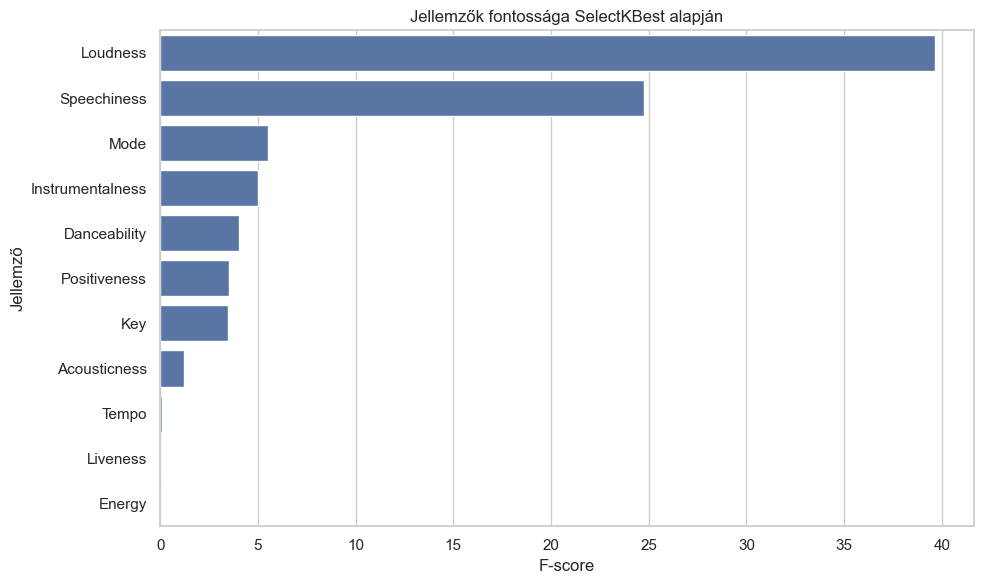

In [20]:
# SelectKBest eredmények vizualizációja
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_scores, x="F-score", y="Jellemző")
plt.title("Jellemzők fontossága SelectKBest alapján")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# Modellek összehasonlítása
models = {
    "Lineáris regresszió": LinearRegression(),
    "Ridge regresszió": Ridge(alpha=1.0),
    "Lasso regresszió": Lasso(alpha=0.01, max_iter=10000),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="r2")

    results.append({
        "Modell": name,
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
        "CV_R2_átlag": cv_scores.mean(),
        "CV_R2_szórás": cv_scores.std()
    })

results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df.round(4)

In [ ]:
# Modell-összehasonlítás vizualizációja
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="R2", y="Modell")
plt.title("Modellek összehasonlítása teszt R² alapján")
plt.tight_layout()
plt.show()

In [ ]:
# Legjobb modell kiválasztása és részletes kiértékelése
best_model_name = results_df.loc[0, "Modell"]
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

print(f"Legjobb modell: {best_model_name}")
print(f"Teszt R²: {r2_score(y_test, y_pred_best):.4f}")
print(f"Teszt RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")
print(f"Teszt MAE: {mean_absolute_error(y_test, y_pred_best):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.7, edgecolor="black")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_title(f"{best_model_name}: valós vs predikált")
axes[0].set_xlabel("Valós Popularity")
axes[0].set_ylabel("Predikált Popularity")

residuals = y_test - y_pred_best
sns.histplot(residuals, bins=25, kde=True, ax=axes[1])
axes[1].set_title("Reziduumok eloszlása")
axes[1].set_xlabel("Reziduum")

plt.tight_layout()
plt.show()

In [ ]:
# Feature importance / koefficiensek
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Jellemző": X_train_scaled.columns,
        "Fontosság": best_model.feature_importances_
    }).sort_values("Fontosság", ascending=False)
elif hasattr(best_model, "coef_"):
    importance_df = pd.DataFrame({
        "Jellemző": X_train_scaled.columns,
        "Fontosság": np.abs(best_model.coef_)
    }).sort_values("Fontosság", ascending=False)
else:
    # biztos fallback
    fallback_model = RandomForestRegressor(n_estimators=200, random_state=42)
    fallback_model.fit(X_train_scaled, y_train)
    importance_df = pd.DataFrame({
        "Jellemző": X_train_scaled.columns,
        "Fontosság": fallback_model.feature_importances_
    }).sort_values("Fontosság", ascending=False)

importance_df

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x="Fontosság", y="Jellemző")
plt.title(f"Legfontosabb jellemzők – {best_model_name}")
plt.tight_layout()
plt.show()

### 5.2 Gyors hiperparaméter hangolás

In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Egyszerű, gyors hiperparaméter-hangolás csak a top modellcsaládra
if best_model_name == "Random Forest":
    tune_model = RandomForestRegressor(random_state=42, n_jobs=-1)
    param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [None, 8, 12],
        "min_samples_split": [2, 5]
    }
elif best_model_name == "Gradient Boosting":
    tune_model = GradientBoostingRegressor(random_state=42)
    param_grid = {
        "n_estimators": [100, 200],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3]
    }
elif best_model_name == "Ridge regresszió":
    tune_model = Ridge()
    param_grid = {
        "alpha": [0.1, 1.0, 10.0, 50.0]
    }
elif best_model_name == "Lasso regresszió":
    tune_model = Lasso(max_iter=10000)
    param_grid = {
        "alpha": [0.001, 0.01, 0.1, 1.0]
    }
else:
    tune_model = LinearRegression()
    param_grid = {
        "fit_intercept": [True, False]
    }

grid_search = GridSearchCV(
    estimator=tune_model,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_tuned_model = grid_search.best_estimator_
y_pred_tuned = best_tuned_model.predict(X_test_scaled)

tuning_summary = pd.Series({
    "Alapmodell": best_model_name,
    "Legjobb paraméterek": str(grid_search.best_params_),
    "Legjobb CV R2": grid_search.best_score_,
    "Hangolt teszt R2": r2_score(y_test, y_pred_tuned),
    "Hangolt teszt RMSE": np.sqrt(mean_squared_error(y_test, y_pred_tuned)),
    "Hangolt teszt MAE": mean_absolute_error(y_test, y_pred_tuned)
}).to_frame("Érték")

tuning_summary

## 7. Eredmények összefoglalása és szakmai következtetések

In [ ]:
top_features = importance_df["Jellemző"].head(3).tolist()

summary_rows = [
    ["Adatforrás", "Spotify Top 50 / kapcsolódó Spotify zenei jellemzők"],
    ["Megfigyelések száma", len(model_df)],
    ["Vizsgált fő zenei jellemzők", ", ".join(model_features)],
    ["Legjobb modell", best_model_name],
    ["Legjobb teszt R²", round(r2_score(y_test, y_pred_best), 4)],
    ["Top 3 fontos jellemző", ", ".join(top_features)]
]

if "country_importance_df" in globals() and isinstance(country_importance_df, pd.DataFrame) and not country_importance_df.empty:
    dominant_feature = country_importance_df["Legfontosabb tényező"].value_counts().idxmax()
    summary_rows.append([
        "Országok között leggyakoribb fő tényező",
        dominant_feature
    ])

summary_df = pd.DataFrame(summary_rows, columns=["Szempont", "Eredmény"])

display(
    summary_df.style
    .hide(axis="index")
    .set_properties(**{
        "text-align": "left",
        "white-space": "normal"
    })
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "left")]},
        {"selector": "td", "props": [("max-width", "600px")]},
    ])
)


In [ ]:
conclusion_lines = []

conclusion_lines.append(f"<li>A dalok átlagos népszerűsége <b>{df['Popularity'].mean():.2f}</b>.</li>")
if "Duration_min" in df.columns:
    conclusion_lines.append(f"<li>Az átlagos dalhossz <b>{df['Duration_min'].mean():.2f} perc</b>.</li>")

if not corr_df.empty:
    strongest = corr_df.iloc[0]
    weakest = corr_df.iloc[-1]
    conclusion_lines.append(
        f"<li>A legerősebb pozitív lineáris kapcsolat a népszerűséggel: "
        f"<b>{strongest['Jellemző']}</b> ({strongest['Pearson-korreláció']:.3f}).</li>"
    )
    conclusion_lines.append(
        f"<li>A legerősebb negatív lineáris kapcsolat a népszerűséggel: "
        f"<b>{weakest['Jellemző']}</b> ({weakest['Pearson-korreláció']:.3f}).</li>"
    )

conclusion_lines.append(
    f"<li>A legjobb prediktív modell: <b>{best_model_name}</b>, teszt R² = <b>{r2_score(y_test, y_pred_best):.4f}</b>.</li>"
)
conclusion_lines.append(
    f"<li>A modell alapján a legfontosabb változók: <b>{', '.join(top_features)}</b>.</li>"
)

if "country_importance_df" in globals() and isinstance(country_importance_df, pd.DataFrame) and not country_importance_df.empty:
    dominant_country_feature = country_importance_df["Legfontosabb tényező"].value_counts().idxmax()
    dominant_count = country_importance_df["Legfontosabb tényező"].value_counts().max()
    conclusion_lines.append(
        f"<li>Az országonkénti bontás alapján a leggyakrabban domináns népszerűségi tényező a "
        f"<b>{dominant_country_feature}</b>, amely <b>{dominant_count}</b> országban bizonyult a legerősebbnek.</li>"
    )

conclusion_lines.append(
    "<li>A zenei jellemzők önmagukban csak részben magyarázzák a sikerességet; "
    "a népszerűségre várhatóan marketing, előadói ismertség, trendek és platformhatások is erősen hatnak.</li>"
)

html_summary = """
<h2>Eredményekből levont fő következtetések</h2>
<ol style="white-space: normal; line-height: 1.7; max-width: 1200px;">
{items}
</ol>
""".format(items="".join(conclusion_lines))

display(HTML(html_summary))



## 8. Továbbfejlesztési lehetőségek

- előadói ismertség és követőszám bevonása,  
- megjelenési idő és trendhatás modellezése,  
- dalszöveg szintű szentimentelemzés,  
- több ország vagy több időpont toplistáinak összehasonlítása,  
- ensemble modellek vagy neurális hálók kipróbálása.


## 9. Források

- Kaggle / Spotify zenei adatállomány  
- `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn` dokumentáció  
- kurzus projektfeladat kiírás